# 07 - External validation on GSE300445

Optional Stage 7 piece (user's choice - the plan marks this "if time
allows"). GSE300445 is a *different* study: 4 primary cutaneous melanoma
Visium sections from an anti-PD1 immunotherapy cohort - no nevus component,
different patients, different clinical context. It cannot validate anything
about the nevus-to-melanoma transition (this project's main question), only
whether the one finding from GSE298774 that survived its own internal
scrutiny - infiltrated tissue tending to sit close to the tumour core
(notebook 05) - shows up independently in unrelated tissue. Same probe
panel (18,085 genes, checked identical - not assumed), much simpler file
layout (one standard matrix per sample, no shared-matrix or missing-barcode
quirks), loaded via new `list_gse300445_samples`/`load_all_gse300445`
functions in `src/geo_loading.py` (unit-tested, `tests/test_geo_loading.py`).

With only 4 samples, "per-library variability" isn't really testable the
way it was with 19 - it's 4 independent checks, not a cohort. Report each
one, don't pool them into a false impression of statistical power.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
from scipy.sparse.csgraph import dijkstra

sys.path.insert(0, str(Path("..") / "src"))
import geo_loading as gl

RAW = Path("..") / "data" / "raw_gse300445"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"


C:\Users\LENOVO\.venvs\melanoma-sg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and QC

Same per-library MAD-based outlier rule as notebook 02 (not a fixed
threshold), applied per sample.

In [2]:
%%time
adatas = gl.load_all_gse300445(RAW, load_images=True)
for name, a in adatas.items():
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    print(f"{name}: {a.n_obs} in-tissue spots, median genes/spot {int(a.obs['n_genes_by_counts'].median())}, "
          f"median UMIs/spot {int(a.obs['total_counts'].median())}")


AdjIII-0019: 2539 in-tissue spots, median genes/spot 8415, median UMIs/spot 34317


AdjIII-0022: 2783 in-tissue spots, median genes/spot 8272, median UMIs/spot 27027
AdjIII-0113: 2145 in-tissue spots, median genes/spot 3538, median UMIs/spot 6742


AdjIII-0133: 4115 in-tissue spots, median genes/spot 8081, median UMIs/spot 36873
CPU times: total: 19.9 s
Wall time: 13.4 s


In [3]:
def is_outlier(values, nmads):
    med = np.median(values)
    mad = median_abs_deviation(values)
    if mad == 0:
        return np.zeros(len(values), dtype=bool)
    return (values < med - nmads * mad) | (values > med + nmads * mad)

qc_summary = []
for name, a in adatas.items():
    outlier = (is_outlier(np.log1p(a.obs["total_counts"].values), 5)
               | is_outlier(np.log1p(a.obs["n_genes_by_counts"].values), 5)
               | is_outlier(a.obs["pct_counts_mt"].values, 3))
    a.obs["qc_outlier"] = outlier
    qc_summary.append({"sample": name, "n_before": a.n_obs, "n_after": int((~outlier).sum())})
print(pd.DataFrame(qc_summary).to_string(index=False))
adatas = {name: a[~a.obs["qc_outlier"]].copy() for name, a in adatas.items()}


     sample  n_before  n_after
AdjIII-0019      2539     2272
AdjIII-0022      2783     2101
AdjIII-0113      2145     1878
AdjIII-0133      4115     3592


## 2. Concatenate, normalise, cluster

Same panel across all 4 samples (checked in notebook memory, not assumed) -
no gene-intersection step needed here, unlike GSE298774.

In [4]:
%%time
for name, a in adatas.items():
    a.obs_names = [f"{name}_{bc}" for bc in a.obs["barcode"]]
    a.var["gene_symbol"] = a.var_names
    a.var_names = a.var["gene_id"].values

combined = ad.concat(adatas, join="inner", merge="first")
combined.var["gene_symbol"] = adatas["AdjIII-0019"].var.loc[combined.var_names, "gene_symbol"].values
combined.var_names = combined.var["gene_symbol"].values
combined.var_names_make_unique()
combined.layers["counts"] = combined.X.copy()
print(combined)

sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
sc.pp.highly_variable_genes(combined, n_top_genes=2000, batch_key="sample")
sc.pp.pca(combined, n_comps=50)
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=50)
sc.tl.umap(combined)
sc.tl.leiden(combined, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2)
combined.obs["cluster"] = "Cluster " + combined.obs["leiden"].astype(str)
print(f"{combined.obs['leiden'].nunique()} clusters, {combined.n_obs} spots total")


AnnData object with n_obs × n_vars = 9843 × 18085
    obs: 'gsm', 'sample', 'barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'qc_outlier'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'
    layers: None (.X), 'counts'


28 clusters, 9843 spots total
CPU times: total: 1min 48s
Wall time: 1min 46s


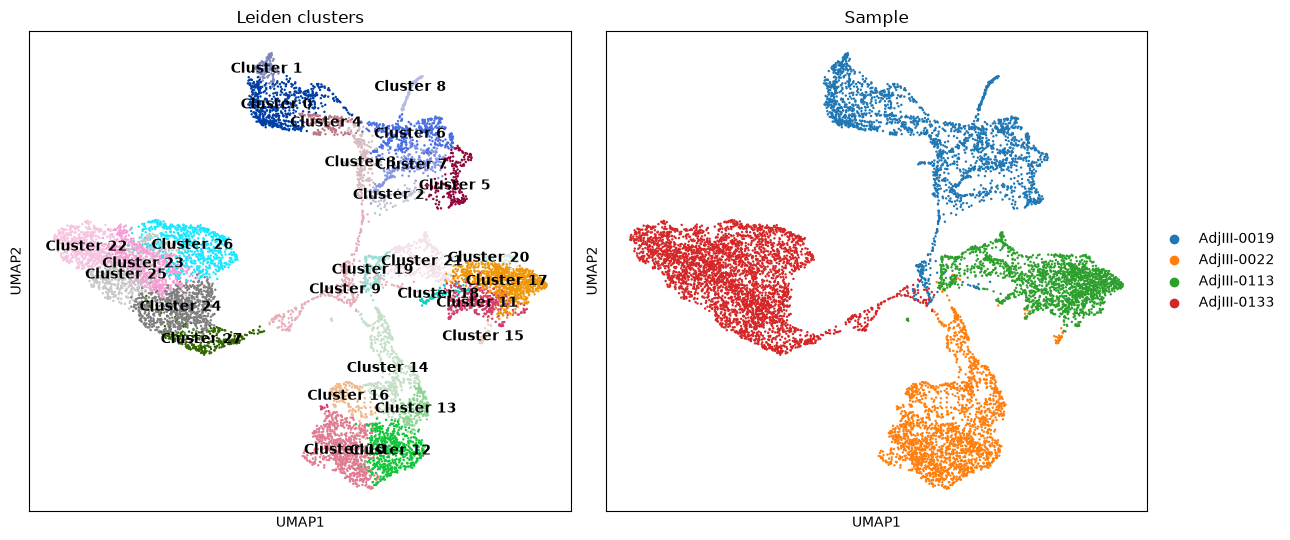

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc.pl.umap(combined, color="cluster", ax=axes[0], show=False, legend_loc="on data", title="Leiden clusters")
sc.pl.umap(combined, color="sample", ax=axes[1], show=False, title="Sample")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "07_umap_overview.png", dpi=150)
plt.show()


## 3. Defining tumour/immune compartments - same method as notebook 05

Marker-panel z-scores across clusters (melanocytic, T_cell, myeloid,
B_plasma - the same panels, same z>1 threshold), not re-tuned for this
dataset, so the comparison against notebook 05 is apples to apples.

In [6]:
marker_sets = {
    "melanocytic": ["MLANA", "PMEL", "TYR", "DCT", "MITF", "S100B"],
    "T_cell": ["CD3D", "CD3E", "CD2"],
    "myeloid": ["CD68", "CD163", "LYZ"],
    "B_plasma": ["CD79A", "MS4A1", "MZB1"],
}
for name, genes in marker_sets.items():
    present = [g for g in genes if g in combined.var_names]
    if len(present) < len(genes):
        print(f"{name}: missing {set(genes) - set(present)}")
    sc.tl.score_genes(combined, present, score_name=f"score_{name}")

cluster_scores = combined.obs.groupby("cluster")[[f"score_{n}" for n in marker_sets]].mean()
cluster_scores.columns = list(marker_sets.keys())
z = (cluster_scores - cluster_scores.mean()) / cluster_scores.std()
print(z.round(2).to_string())

is_tumour_like = z["melanocytic"] > 1.0
is_immune_like = z[["T_cell", "myeloid", "B_plasma"]].max(axis=1) > 1.0

def compartment(cl):
    t, i = is_tumour_like[cl], is_immune_like[cl]
    if t and i:
        return "tumour_infiltrated"
    if t and not i:
        return "tumour_cold"
    if i and not t:
        return "immune_only"
    return "other"

compartment_map = {cl: compartment(cl) for cl in z.index}
combined.obs["compartment"] = combined.obs["cluster"].map(compartment_map).astype("category")
comp_counts = combined.obs["compartment"].value_counts()
print(comp_counts)
pd.DataFrame({"cluster": compartment_map.keys(), "compartment": compartment_map.values()}).to_csv(
    TABLES_OUT / "gse300445_cluster_compartment_definitions.csv", index=False)


            melanocytic  T_cell  myeloid  B_plasma
cluster                                           
Cluster 0          0.00   -0.52    -0.90     -0.13
Cluster 1         -0.01   -0.50    -0.80     -0.22
Cluster 2         -0.68    2.21     1.26      1.53
Cluster 3         -0.54    0.42     0.40      0.90
Cluster 4          0.06   -0.59    -0.89     -0.18
Cluster 5          1.33   -0.45    -0.41     -0.40
Cluster 6          1.52   -0.31    -0.13     -0.39
Cluster 7          1.33    0.79     0.87      1.11
Cluster 8          2.31   -0.53    -1.25     -0.32
Cluster 9         -0.97    0.88     0.49      3.48
Cluster 10         0.54   -0.57    -0.77     -0.31
Cluster 11        -1.03    0.03     0.68     -0.20
Cluster 12         0.73   -0.62    -1.06     -0.04
Cluster 13         1.46   -0.65    -1.13     -0.02
Cluster 14         1.53   -0.72    -0.88     -0.26
Cluster 15        -1.29   -0.74    -0.66     -2.18
Cluster 16         0.50   -0.51    -0.40     -0.41
Cluster 17        -0.85   -0.18

## 4. Distance-to-tumour-core, same hop-count method as notebook 05

If `tumour_cold` doesn't exist in this dataset (possible - it's a different
tumour biology, anti-PD1 cohort, not necessarily the same cold/infiltrated
split), that itself is reported, not forced.

In [7]:
usable = []
if "tumour_cold" not in combined.obs["compartment"].cat.categories or (combined.obs["compartment"] == "tumour_cold").sum() < 20:
    print("tumour_cold compartment doesn't exist or is too small in this dataset - "
          "the notebook 05 comparison cannot be run the same way here")
else:
    sq.gr.spatial_neighbors_grid(combined, library_key="sample", n_neighs=6)
    tumour_idx = np.flatnonzero((combined.obs["compartment"] == "tumour_cold").values)
    hop = dijkstra(combined.obsp["spatial_connectivities"], directed=False, indices=tumour_idx,
                    unweighted=True, min_only=True)
    combined.obs["hops_to_tumour_core"] = hop
    combined.obs.loc[~np.isfinite(hop), "hops_to_tumour_core"] = np.nan
    print(f"{len(tumour_idx)} tumour-core spots across "
          f"{combined.obs.loc[combined.obs['compartment']=='tumour_cold','sample'].nunique()} samples")

    per_sample_core_n = combined.obs[combined.obs["compartment"] == "tumour_cold"].groupby("sample", observed=True).size()
    usable = per_sample_core_n[per_sample_core_n >= 20].index.tolist()
    print(f"samples with >=20 tumour-core spots: {usable}")


INFO     Creating graph using `None` transform and `4` libraries.                                                  


1269 tumour-core spots across 2 samples
samples with >=20 tumour-core spots: ['AdjIII-0019', 'AdjIII-0022']


compartment  immune_only  other  tumour_cold  tumour_infiltrated
hop_bin                                                         
0                  0.000  0.000          1.0               0.000
1                  0.129  0.621          0.0               0.250
2                  0.112  0.671          0.0               0.217
3                  0.096  0.709          0.0               0.196
4                  0.122  0.751          0.0               0.127
5                  0.126  0.856          0.0               0.018
6                  0.094  0.888          0.0               0.019
7                  0.079  0.894          0.0               0.026
8                  0.049  0.923          0.0               0.028
9                  0.043  0.928          0.0               0.029
10                 0.066  0.912          0.0               0.022
11                 0.032  0.944          0.0               0.024
12                 0.000  0.973          0.0               0.027
13                 0.000 

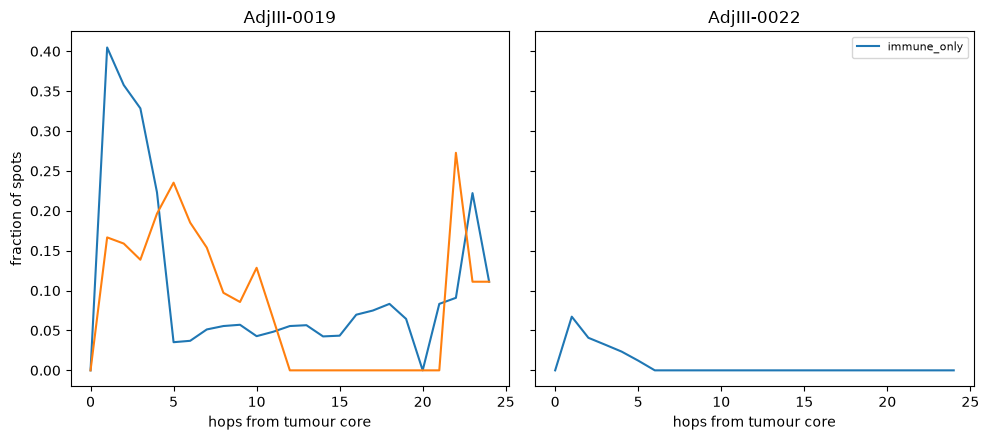

In [8]:
if usable:
    sub = combined.obs[combined.obs["sample"].isin(usable) & combined.obs["hops_to_tumour_core"].notna()].copy()
    bin_counts = sub["hops_to_tumour_core"].astype(int).value_counts().sort_index()
    MIN_BIN_N = 30
    max_hop = int(bin_counts[bin_counts >= MIN_BIN_N].index.max()) if (bin_counts >= MIN_BIN_N).any() else int(bin_counts.index.max())
    sub["hop_bin"] = sub["hops_to_tumour_core"].astype(int)
    sub = sub[sub["hop_bin"] <= max_hop]
    frac_by_hop = pd.crosstab(sub["hop_bin"], sub["compartment"], normalize="index")
    frac_by_hop.to_csv(TABLES_OUT / "gse300445_compartment_fraction_by_distance.csv")
    print(frac_by_hop.round(3).to_string())

    fig, axes = plt.subplots(1, len(usable), figsize=(5 * len(usable), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, s in zip(axes, usable):
        s_sub = sub[sub["sample"] == s]
        for comp, color in [("tumour_infiltrated", "tab:purple"), ("immune_only", "tab:blue")]:
            if comp in s_sub["compartment"].values:
                frac = s_sub.groupby("hop_bin", observed=True)["compartment"].apply(lambda x: (x == comp).mean())
                ax.plot(frac.index, frac.values, label=comp)
        ax.set_title(s)
        ax.set_xlabel("hops from tumour core")
    axes[0].set_ylabel("fraction of spots")
    axes[-1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_OUT / "07_compartment_fraction_by_distance.png", dpi=150)
    plt.show()


## 5. Which samples actually have both compartments to compare

Learned from notebook 05's B1 lesson: check the per-sample compartment
counts directly before reading any peak-hop number as "the" result -
a compartment that exists in only one sample out of four is a single data
point, not a replicated finding, no matter how clean its own curve looks.

In [9]:
per_sample_compartment = combined.obs.groupby(["sample", "compartment"], observed=True).size().unstack(fill_value=0)
print(per_sample_compartment.to_string())


compartment  immune_only  other  tumour_cold  tumour_infiltrated
sample                                                          
AdjIII-0019          250   1090          689                 243
AdjIII-0022           17   1504          580                   0
AdjIII-0113          549   1329            0                   0
AdjIII-0133          142   3450            0                   0


## 6. Summary

In [10]:
combined.write_h5ad(PROCESSED_OUT / "07_gse300445_validated.h5ad")
n_samples_with_infiltrated = int((per_sample_compartment.get("tumour_infiltrated", 0) >= 20).sum())
n_samples_with_cold = int((per_sample_compartment.get("tumour_cold", 0) >= 20).sum())
print("Observed, from this notebook's own computation:")
print(f"- {combined.n_obs} spots across 4 GSE300445 samples, {combined.obs['leiden'].nunique()} clusters")
print(f"- Compartments found: {dict(comp_counts)}")
print(f"- tumour_cold present (>=20 spots) in {n_samples_with_cold}/4 samples; "
      f"tumour_infiltrated present (>=20 spots) in {n_samples_with_infiltrated}/4 samples")
if usable:
    for s in usable:
        s_sub = sub[sub["sample"] == s]
        if "tumour_infiltrated" in s_sub["compartment"].values:
            frac = s_sub.groupby("hop_bin", observed=True)["compartment"].apply(lambda x: (x == "tumour_infiltrated").mean())
            print(f"  {s}: tumour_infiltrated fraction peaks at hop {frac.idxmax()} (value {frac.max():.3f})")
        else:
            print(f"  {s}: has tumour_cold but no tumour_infiltrated compartment at all - pattern not testable here")
else:
    print("- Could not test the distance pattern in this dataset (see section 4)")
print("wrote data/processed/07_gse300445_validated.h5ad")


Observed, from this notebook's own computation:
- 9843 spots across 4 GSE300445 samples, 28 clusters
- Compartments found: {'other': np.int64(7373), 'tumour_cold': np.int64(1269), 'immune_only': np.int64(958), 'tumour_infiltrated': np.int64(243)}
- tumour_cold present (>=20 spots) in 2/4 samples; tumour_infiltrated present (>=20 spots) in 1/4 samples
  AdjIII-0019: tumour_infiltrated fraction peaks at hop 1 (value 0.405)
  AdjIII-0022: has tumour_cold but no tumour_infiltrated compartment at all - pattern not testable here
wrote data/processed/07_gse300445_validated.h5ad


**The honest read of this validation is narrower than the section 4
table alone suggests.** Only **one of four samples (AdjIII-0019)** has
enough spots in both `tumour_cold` and `tumour_infiltrated` to test
notebook 05's pattern at all - and in that one sample, the peak is
immediate and clean (hop 1, 40.5% of spots - even sharper than GSE298774's
own peak). AdjIII-0022 has a tumour_cold core but *no* tumour_infiltrated
compartment anywhere in the sample; the other two samples (AdjIII-0113,
AdjIII-0133) have neither - no clearly melanocytic-elevated cluster was
found in them at all under this z>1 threshold, so the question doesn't
even apply to them.

This is one corroborating data point from an independent study, not a
replicated finding across a second cohort - a single match is worth
reporting (it's the same direction, and a sharper version of it, in tissue
this project's pipeline never touched before), but it would be a real
overclaim to say "the pattern validates in GSE300445" when 3 of its 4
samples couldn't be tested at all. Given GSE300445 is also a different
clinical context (anti-PD1 cohort, no nevus component), even a clean match
supports only the general tumour-immune-proximity pattern, not anything
about the nevus-to-melanoma question GSE298774 was built around.